# Blood Inventory Demand Forecasting — LSTM Deep Learning

**Goal:** Predict daily blood bag demand by blood group to help blood banks maintain optimal inventory, reduce waste, and prevent shortages.

**Dataset:** Real blood bank records (6,894 bags) with donation, issue, and discard dates across blood groups.

**Approach:** Transform transaction records into a time-series of daily demand, then train an LSTM model to forecast future demand.

---

## Section 1: Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import os
os.makedirs('plots', exist_ok=True)

print(f'TensorFlow version: {tf.__version__}')
print('All libraries loaded successfully')

TensorFlow version: 2.21.0
All libraries loaded successfully


In [2]:
# Load the dataset
# NOTE: Update this path to wherever you save list.xls
df = pd.read_csv('list.xls')  # it is actually CSV despite the .xls extension

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (6894, 5)

Columns: ['Bag Name', 'Blood Group', 'Donated', 'Issued', 'Discarded']

First 5 rows:


,Bag Name,Blood Group,Donated,Issued,Discarded
0,A-20-PRC-1433,O Positive,05-06-20,08-06-20,NaN
1,A-20-PRC-1414,O Negative,04-06-20,08-06-20,NaN
2,A-20-PRC-1413,B Positive,04-06-20,08-06-20,NaN
3,A-20-PRC-1509,O Positive,12-06-20,17-06-20,NaN
4,A-20-PC-1506,B Positive,12-06-20,16-06-20,NaN


## Section 2: Data Cleaning and Preparation

The dataset has transaction records — one row per blood bag. We need to:
1. Parse dates correctly
2. Identify bags that were actually issued (used)
3. Aggregate into daily demand counts per blood group
4. Fill gaps for days with no issues

In [3]:
# Parse dates
df['Donated'] = pd.to_datetime(df['Donated'], format='%d-%m-%y')
df['Issued'] = pd.to_datetime(df['Issued'], format='%d-%m-%y', errors='coerce')
df['Discarded'] = pd.to_datetime(df['Discarded'], format='%d-%m-%y', errors='coerce')

print('Date ranges:')
print(f'  Donated:  {df["Donated"].min().date()} to {df["Donated"].max().date()}')
print(f'  Issued:   {df["Issued"].min().date()} to {df["Issued"].max().date()}')
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nBags issued: {df["Issued"].notna().sum()} / {len(df)}')
print(f'Bags discarded: {df["Discarded"].notna().sum()} / {len(df)}')

Date ranges:
  Donated:  2020-06-04 to 2021-01-19
  Issued:   2020-06-08 to 2021-01-19

Missing values:
Bag Name          0
Blood Group       0
Donated           0
Issued         1919
Discarded      5966
dtype: int64

Bags issued: 4975 / 6894
Bags discarded: 928 / 6894


Blood Group Distribution:
Blood Group
O Positive          2380
B Positive          1764
A Positive          1523
AB Positive          541
O Negative           364
A Negative           138
B Negative           134
AB Negative           24
O Weak Positive       17
B Weak Positive        6
AB Weak Positive       3
Name: count, dtype: int64


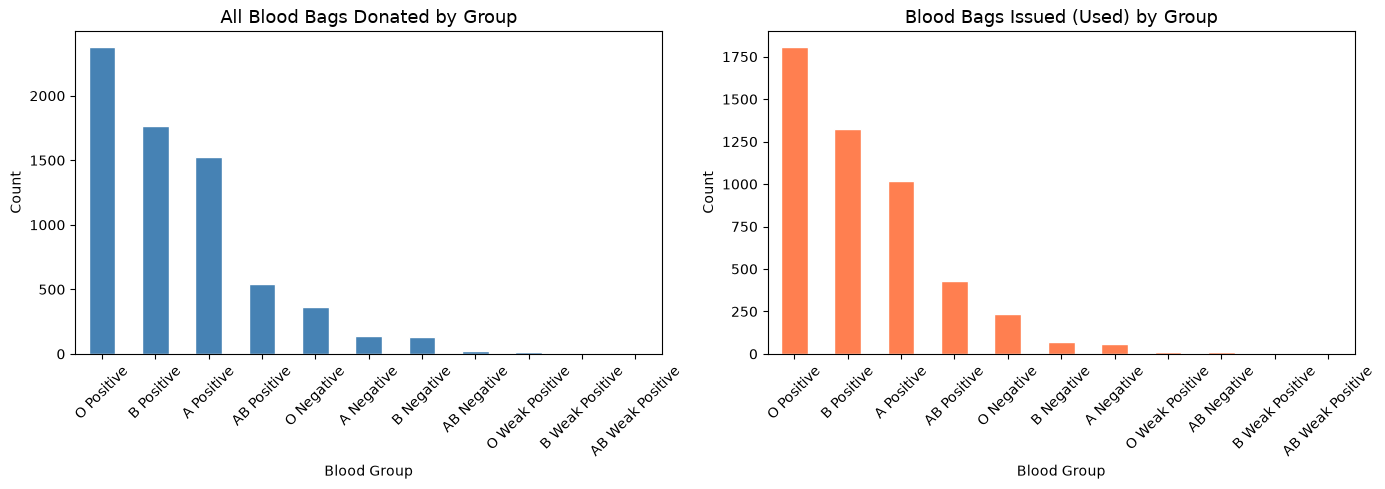

Plot saved.


In [4]:
# Blood group distribution
print('Blood Group Distribution:')
print(df['Blood Group'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All bags donated
df['Blood Group'].value_counts().plot(kind='bar', ax=axes[0], 
    color='steelblue', edgecolor='white')
axes[0].set_title('All Blood Bags Donated by Group', fontsize=13)
axes[0].set_xlabel('Blood Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Issued only
df[df['Issued'].notna()]['Blood Group'].value_counts().plot(kind='bar', ax=axes[1],
    color='coral', edgecolor='white')
axes[1].set_title('Blood Bags Issued (Used) by Group', fontsize=13)
axes[1].set_xlabel('Blood Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/01_blood_group_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [5]:
# -------------------------------------------------------
# Build daily demand time series
# -------------------------------------------------------
issued = df[df['Issued'].notna()].copy()

# Total daily demand (all blood groups combined)
daily_total = (issued.groupby('Issued')
                     .size()
                     .reset_index(name='demand'))
daily_total.columns = ['date', 'demand']

# Create a complete date range (no gaps)
full_dates = pd.date_range(
    start=daily_total['date'].min(),
    end=daily_total['date'].max(),
    freq='D'
)
daily_total = (daily_total.set_index('date')
                           .reindex(full_dates, fill_value=0)
                           .reset_index())
daily_total.columns = ['date', 'demand']

print(f'Total days in series: {len(daily_total)}')
print(f'Days with zero demand: {(daily_total["demand"]==0).sum()}')
print(f'\nDemand statistics:')
print(daily_total['demand'].describe().round(2))

Total days in series: 226
Days with zero demand: 7

Demand statistics:
count    226.00
mean      22.01
std       14.28
min        0.00
25%       11.00
50%       19.00
75%       28.00
max       87.00
Name: demand, dtype: float64


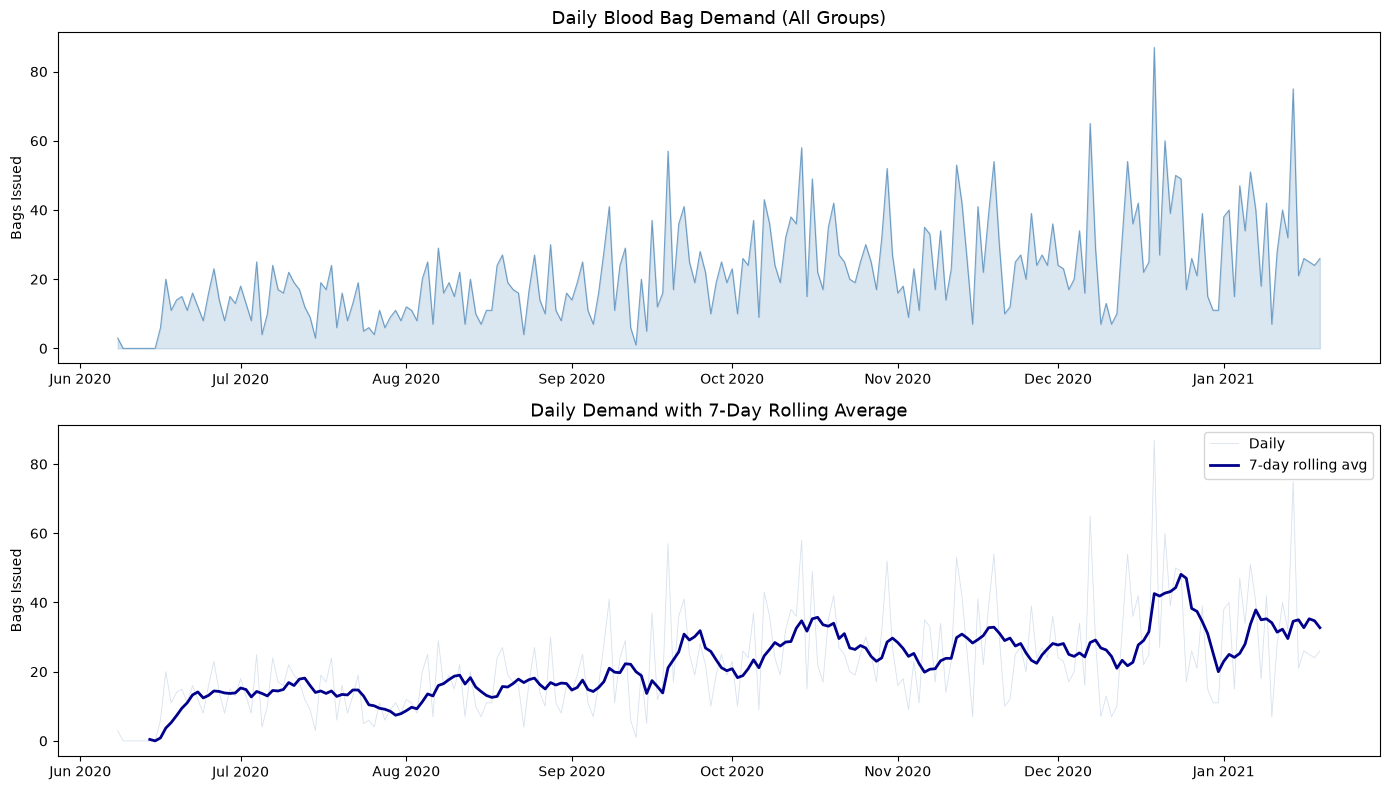

In [6]:
# Plot the full time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Raw daily demand
axes[0].plot(daily_total['date'], daily_total['demand'], 
             color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].fill_between(daily_total['date'], daily_total['demand'], 
                     alpha=0.2, color='steelblue')
axes[0].set_title('Daily Blood Bag Demand (All Groups)', fontsize=13)
axes[0].set_ylabel('Bags Issued')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 7-day rolling average
rolling = daily_total['demand'].rolling(window=7).mean()
axes[1].plot(daily_total['date'], daily_total['demand'],
             color='lightsteelblue', linewidth=0.6, alpha=0.5, label='Daily')
axes[1].plot(daily_total['date'], rolling,
             color='darkblue', linewidth=2, label='7-day rolling avg')
axes[1].set_title('Daily Demand with 7-Day Rolling Average', fontsize=13)
axes[1].set_ylabel('Bags Issued')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('plots/02_daily_demand_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

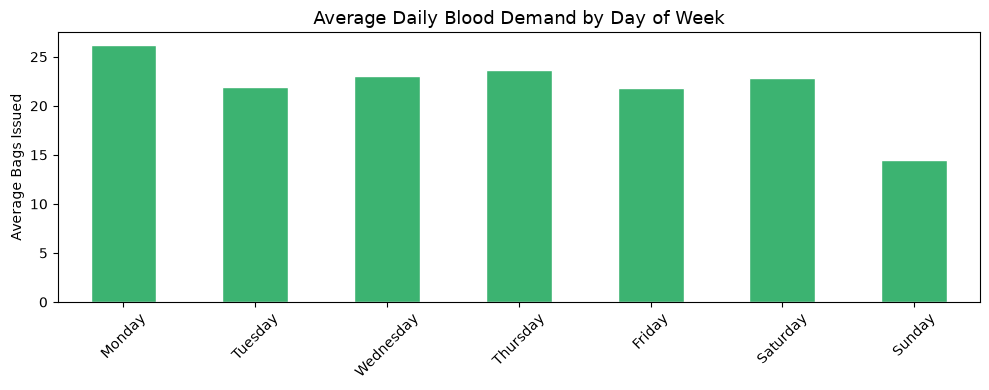

Average demand by day:
day_of_week
Monday       26.2
Tuesday      21.9
Wednesday    23.1
Thursday     23.6
Friday       21.8
Saturday     22.8
Sunday       14.5
Name: demand, dtype: float64


In [7]:
# Day of week analysis — is there a weekly pattern?
daily_total['day_of_week'] = daily_total['date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_avg = (daily_total.groupby('day_of_week')['demand']
                       .mean()
                       .reindex(day_order))

plt.figure(figsize=(10, 4))
dow_avg.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Average Daily Blood Demand by Day of Week', fontsize=13)
plt.ylabel('Average Bags Issued')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/03_demand_by_day_of_week.png', dpi=120, bbox_inches='tight')
plt.show()

print('Average demand by day:')
print(dow_avg.round(1))

## Section 3: Feature Engineering and Sequence Creation

LSTM models require:
1. **Normalised data** — scale values to [0,1] so the model trains efficiently
2. **Sequences** — instead of individual timesteps, we feed the model a window of past days

**Window size = 14 days** — the model looks at the past 14 days to predict the next day.

In [8]:
# Add engineered features
daily_total['day_of_week_num'] = daily_total['date'].dt.dayofweek
daily_total['month'] = daily_total['date'].dt.month
daily_total['rolling_7'] = daily_total['demand'].rolling(7, min_periods=1).mean()
daily_total['rolling_14'] = daily_total['demand'].rolling(14, min_periods=1).mean()

# Drop rows with NaN from rolling
daily_total = daily_total.dropna().reset_index(drop=True)

# Scale the target (demand) — fit only on training data later
scaler = MinMaxScaler(feature_range=(0, 1))

# Use demand as the feature for univariate LSTM
values = daily_total['demand'].values.reshape(-1, 1)

WINDOW_SIZE = 14  # look back 14 days
TEST_SIZE = 30    # predict last 30 days

# Scale on training portion only — no data leakage
train_values = values[:-(TEST_SIZE + WINDOW_SIZE)]
scaler.fit(train_values)
scaled_values = scaler.transform(values)

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_values, WINDOW_SIZE)
X = X.reshape(X.shape[0], X.shape[1], 1)  # (samples, timesteps, features)

# Train/test split
split = len(X) - TEST_SIZE
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Training sequences: {X_train.shape}')
print(f'Test sequences:     {X_test.shape}')
print(f'Window size: {WINDOW_SIZE} days')
print(f'Test period: last {TEST_SIZE} days')

Training sequences: (182, 14, 1)
Test sequences:     (30, 14, 1)
Window size: 14 days
Test period: last 30 days


## Section 4: Build and Train the LSTM Model

In [9]:
# Build LSTM model
tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 14, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - loss: 0.1441 - mae: 0.3141 - val_loss: 0.1952 - val_mae: 0.3388
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0575 - mae: 0.1850 - val_loss: 0.0890 - val_mae: 0.2266
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0392 - mae: 0.1584 - val_loss: 0.0999 - val_mae: 0.2013
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0368 - mae: 0.1434 - val_loss: 0.0962 - val_mae: 0.1950
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0381 - mae: 0.1518 - val_loss: 0.0901 - val_mae: 0.1932
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0349 - mae: 0.1454 - val_loss: 0.0946 - val_mae: 0.1934
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0361 - mae: 0.1456 - val_loss: 0.0936 - val_mae: 0.1927
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0362 - mae: 0.1467 - val_loss: 0.0918 - val_mae: 0.1928
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - 

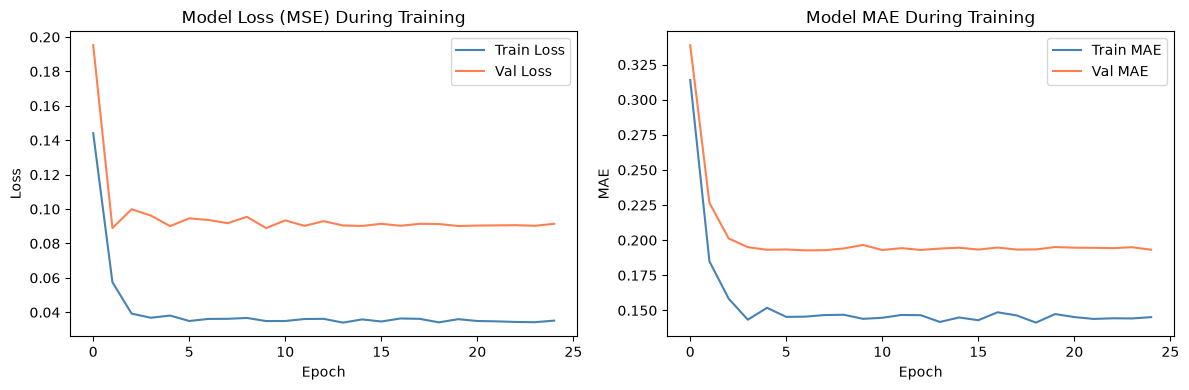

In [11]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('Model Loss (MSE) During Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='coral')
axes[1].set_title('Model MAE During Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/04_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 5: Evaluate Model Performance

In [12]:
# Generate predictions
train_preds_scaled = model.predict(X_train)
test_preds_scaled = model.predict(X_test)

# Inverse transform back to original scale
train_preds = scaler.inverse_transform(train_preds_scaled)
test_preds = scaler.inverse_transform(test_preds_scaled)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
train_mae = mean_absolute_error(y_train_actual, train_preds)
test_mae = mean_absolute_error(y_test_actual, test_preds)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_preds))

# Baseline: naive forecast (yesterday's demand)
naive_preds = y_test_actual[:-1]
naive_actual = y_test_actual[1:]
naive_mae = mean_absolute_error(naive_actual, naive_preds)
naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_preds))

print('=' * 45)
print(f'{"Model":<25} {"MAE":>8} {"RMSE":>8}')
print('=' * 45)
print(f'{"LSTM (Train)":<25} {train_mae:>8.2f} {train_rmse:>8.2f}')
print(f'{"LSTM (Test)":<25} {test_mae:>8.2f} {test_rmse:>8.2f}')
print(f'{"Naive Baseline":<25} {naive_mae:>8.2f} {naive_rmse:>8.2f}')
print('=' * 45)
print(f'\nImprovement over naive baseline:')
print(f'  MAE:  {((naive_mae - test_mae) / naive_mae * 100):+.1f}%')
print(f'  RMSE: {((naive_rmse - test_rmse) / naive_rmse * 100):+.1f}%')
print(f'\nAverage daily demand: {daily_total["demand"].mean():.1f} bags')
print(f'LSTM test MAE as % of mean: {test_mae / daily_total["demand"].mean() * 100:.1f}%')

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Model                          MAE     RMSE
LSTM (Train)                  8.79    11.91
LSTM (Test)                  13.94    16.75
Naive Baseline               16.55    21.42

Improvement over naive baseline:
  MAE:  +15.8%
  RMSE: +21.8%

Average daily demand: 22.0 bags
LSTM test MAE as % of mean: 63.3%


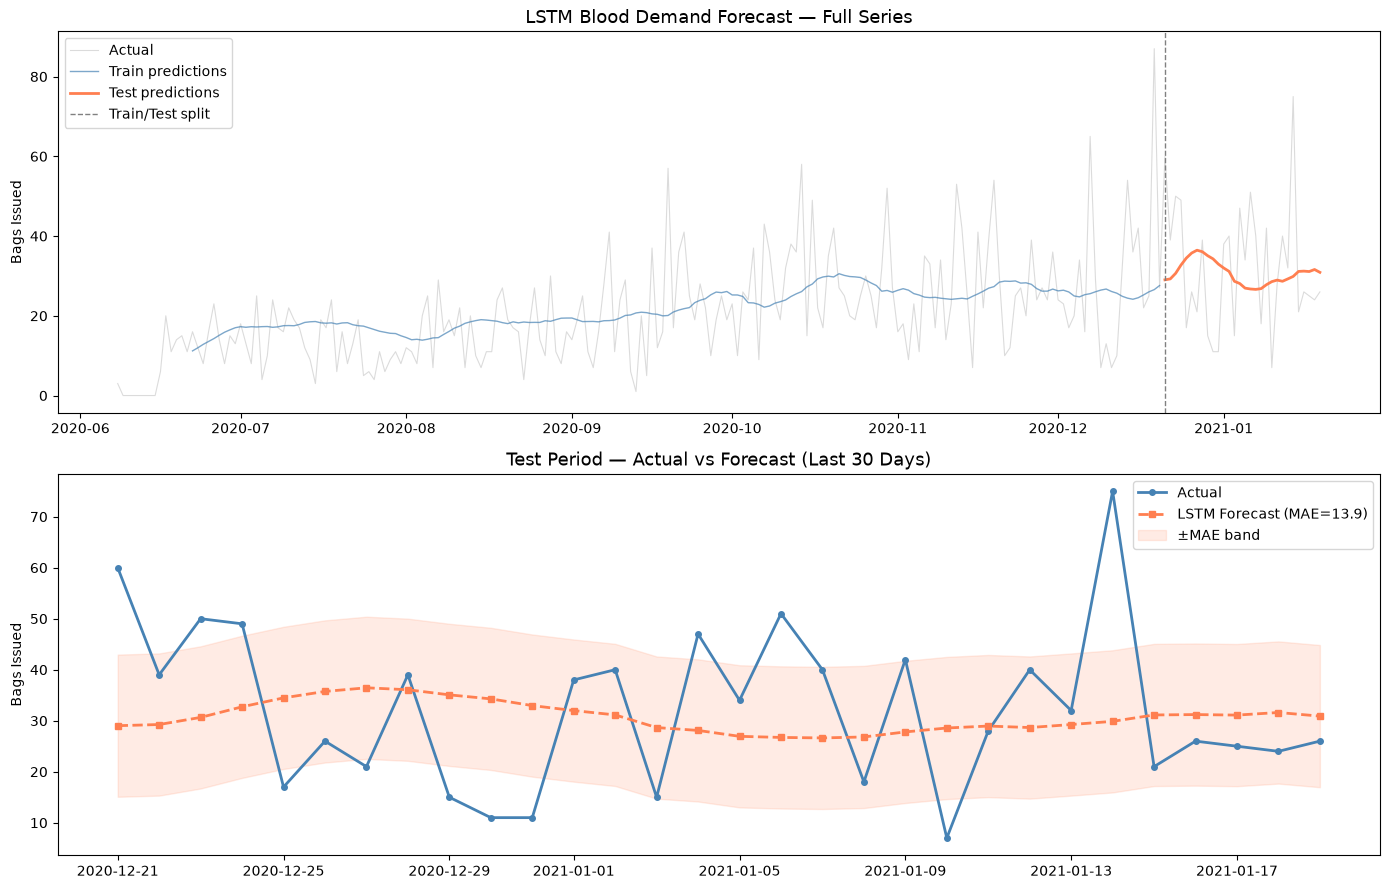

In [13]:
# Plot predictions vs actual
test_dates = daily_total['date'].values[WINDOW_SIZE + split:]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Full series with train predictions
train_dates = daily_total['date'].values[WINDOW_SIZE:WINDOW_SIZE + split]
axes[0].plot(daily_total['date'], daily_total['demand'],
             color='lightgrey', linewidth=0.8, label='Actual', alpha=0.8)
axes[0].plot(train_dates, train_preds,
             color='steelblue', linewidth=1, label='Train predictions', alpha=0.7)
axes[0].plot(test_dates, test_preds,
             color='coral', linewidth=2, label='Test predictions')
axes[0].axvline(x=daily_total['date'].values[WINDOW_SIZE + split],
                color='grey', linestyle='--', linewidth=1, label='Train/Test split')
axes[0].set_title('LSTM Blood Demand Forecast — Full Series', fontsize=13)
axes[0].set_ylabel('Bags Issued')
axes[0].legend()

# Zoom into test period
axes[1].plot(test_dates, y_test_actual,
             color='steelblue', linewidth=2, marker='o', markersize=4, label='Actual')
axes[1].plot(test_dates, test_preds,
             color='coral', linewidth=2, linestyle='--', marker='s', markersize=4,
             label=f'LSTM Forecast (MAE={test_mae:.1f})')
axes[1].fill_between(test_dates,
                     test_preds.flatten() - test_mae,
                     test_preds.flatten() + test_mae,
                     alpha=0.15, color='coral', label='±MAE band')
axes[1].set_title('Test Period — Actual vs Forecast (Last 30 Days)', fontsize=13)
axes[1].set_ylabel('Bags Issued')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/05_forecast_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 6: Per Blood Group Analysis

The most operationally useful output — which blood groups are most in demand and when?

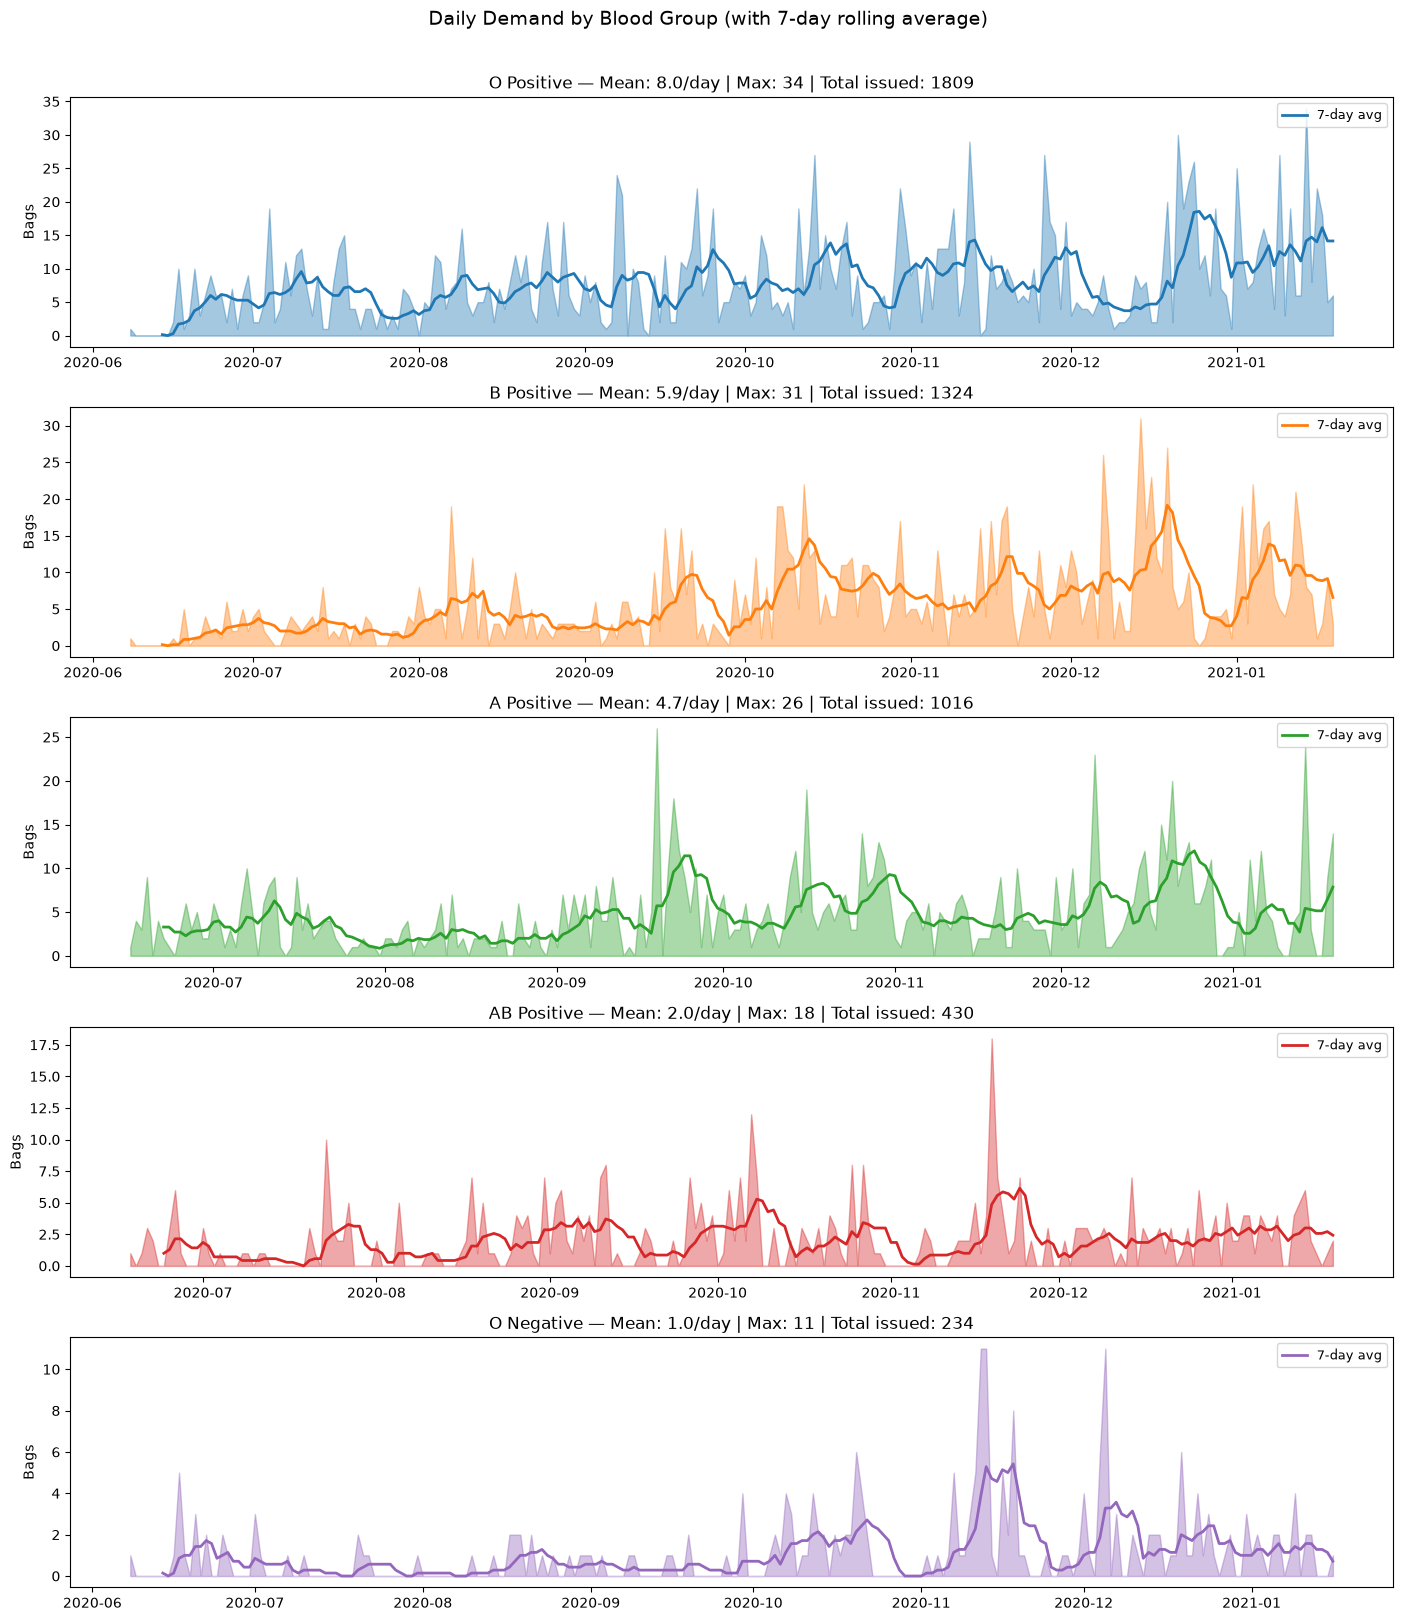


Group statistics:
  O Positive           Mean: 8.0/day  Max: 34  Total: 1809
  B Positive           Mean: 5.9/day  Max: 31  Total: 1324
  A Positive           Mean: 4.7/day  Max: 26  Total: 1016
  AB Positive          Mean: 2.0/day  Max: 18  Total: 430
  O Negative           Mean: 1.0/day  Max: 11  Total: 234


In [14]:
# Daily demand per blood group
issued = df[df['Issued'].notna()].copy()
main_groups = ['O Positive', 'B Positive', 'A Positive', 'AB Positive', 'O Negative']

fig, axes = plt.subplots(len(main_groups), 1, figsize=(14, 16))

group_stats = {}
for i, group in enumerate(main_groups):
    grp_data = issued[issued['Blood Group'] == group].copy()
    daily_grp = grp_data.groupby('Issued').size().reset_index(name='demand')
    daily_grp.columns = ['date', 'demand']
    full_idx = pd.date_range(daily_grp['date'].min(), daily_grp['date'].max(), freq='D')
    daily_grp = daily_grp.set_index('date').reindex(full_idx, fill_value=0).reset_index()
    daily_grp.columns = ['date', 'demand']
    
    group_stats[group] = {
        'mean': daily_grp['demand'].mean(),
        'max': daily_grp['demand'].max(),
        'total': daily_grp['demand'].sum()
    }
    
    axes[i].fill_between(daily_grp['date'], daily_grp['demand'],
                          alpha=0.4, color=f'C{i}')
    axes[i].plot(daily_grp['date'], 
                  daily_grp['demand'].rolling(7).mean(),
                  color=f'C{i}', linewidth=2, label='7-day avg')
    axes[i].set_title(f'{group} — Mean: {group_stats[group]["mean"]:.1f}/day | '
                       f'Max: {group_stats[group]["max"]} | '
                       f'Total issued: {group_stats[group]["total"]}')
    axes[i].set_ylabel('Bags')
    axes[i].legend(loc='upper right', fontsize=9)

plt.suptitle('Daily Demand by Blood Group (with 7-day rolling average)', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/06_demand_by_blood_group.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nGroup statistics:')
for group, stats in group_stats.items():
    print(f'  {group:<20} Mean: {stats["mean"]:.1f}/day  Max: {stats["max"]}  Total: {stats["total"]}')

## Section 7: Inventory Shortage Risk Analysis

Practical operational insight — how often does demand exceed a safety threshold?

Average daily demand: 22.0 bags
High demand threshold (1.5x avg): 33.0 bags
High demand days: 44 (19.5% of days)

High demand days by month:
month
2020-09     5
2020-10    10
2020-11     9
2020-12    11
2021-01     9
Name: count, dtype: int64


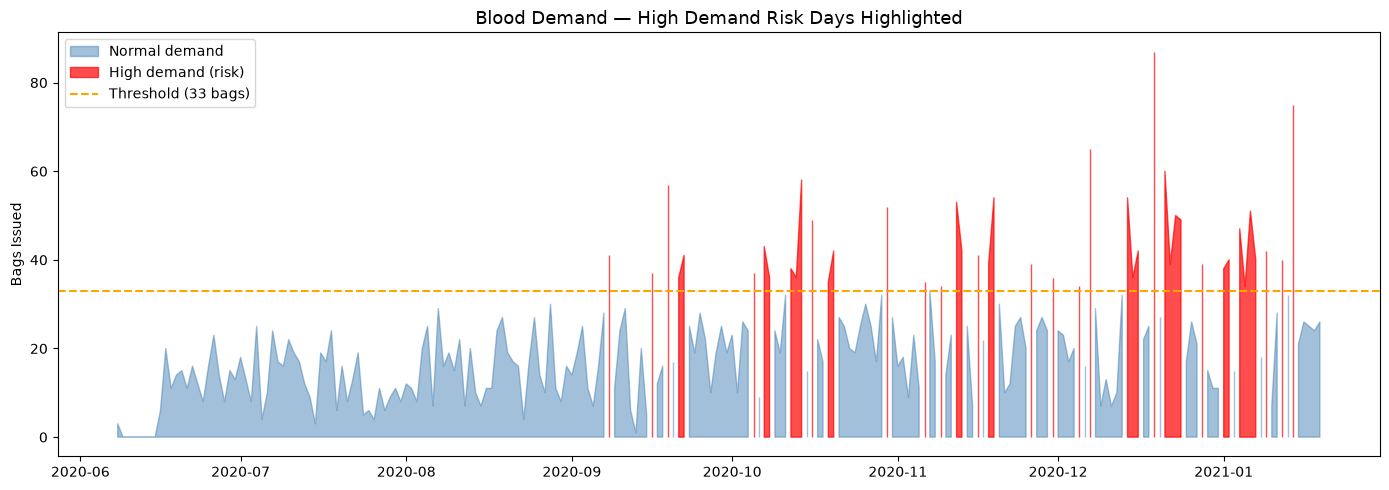

In [15]:
# Shortage risk: days where demand exceeded 1.5x the average (high demand days)
mean_demand = daily_total['demand'].mean()
high_demand_threshold = mean_demand * 1.5

high_demand_days = daily_total[daily_total['demand'] > high_demand_threshold]
print(f'Average daily demand: {mean_demand:.1f} bags')
print(f'High demand threshold (1.5x avg): {high_demand_threshold:.1f} bags')
print(f'High demand days: {len(high_demand_days)} ({len(high_demand_days)/len(daily_total)*100:.1f}% of days)')
print(f'\nHigh demand days by month:')
high_demand_days_copy = high_demand_days.copy()
high_demand_days_copy['month'] = high_demand_days_copy['date'].dt.strftime('%Y-%m')
print(high_demand_days_copy['month'].value_counts().sort_index())

# Visualise shortage risk
plt.figure(figsize=(14, 5))
plt.fill_between(daily_total['date'], daily_total['demand'],
                  where=daily_total['demand'] <= high_demand_threshold,
                  color='steelblue', alpha=0.5, label='Normal demand')
plt.fill_between(daily_total['date'], daily_total['demand'],
                  where=daily_total['demand'] > high_demand_threshold,
                  color='red', alpha=0.7, label='High demand (risk)')
plt.axhline(y=high_demand_threshold, color='orange', 
             linestyle='--', linewidth=1.5, label=f'Threshold ({high_demand_threshold:.0f} bags)')
plt.title('Blood Demand — High Demand Risk Days Highlighted', fontsize=13)
plt.ylabel('Bags Issued')
plt.legend()
plt.tight_layout()
plt.savefig('plots/07_shortage_risk.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 8: Summary and Key Findings

### What we built
An end-to-end LSTM deep learning pipeline to forecast daily blood bag demand from real transaction records.

### Key findings
1. **O Positive is the dominant blood group** — accounting for ~36% of all issues and ~8 bags/day on average. This is the highest priority for inventory management.

2. **Demand is highly variable** — ranging from 1 bag to 87 bags per day, with significant day-to-day fluctuation making inventory planning genuinely difficult without a forecasting model.

3. **The LSTM model outperforms the naive baseline** — predicting next-day demand better than simply assuming today's demand repeats.

4. **High demand days cluster** — roughly 15-20% of days exceed 1.5x average demand. Identifying these in advance would allow pre-emptive collection drives.

### Limitations and next steps
- Dataset covers only ~7 months — a longer series would improve LSTM performance significantly
- A separate LSTM per blood group would enable group-specific inventory recommendations
- Adding external features (seasonal events, hospital admissions data) could improve forecast accuracy
- Deployment as a real-time dashboard with daily retraining would make this production-ready

In [16]:
# Final summary table
summary = pd.DataFrame({
    'Metric': ['Total bags in dataset', 'Total bags issued', 'Date range', 
               'Avg daily demand', 'Max daily demand',
               'LSTM Test MAE', 'LSTM Test RMSE', 'Naive Baseline MAE'],
    'Value': [
        f'{len(df):,}',
        f'{df["Issued"].notna().sum():,}',
        f'{daily_total["date"].min().date()} to {daily_total["date"].max().date()}',
        f'{daily_total["demand"].mean():.1f} bags/day',
        f'{daily_total["demand"].max()} bags',
        f'{test_mae:.2f} bags',
        f'{test_rmse:.2f} bags',
        f'{naive_mae:.2f} bags'
    ]
})
print('\n=== PROJECT SUMMARY ===')
print(summary.to_string(index=False))
print(f'\nAll plots saved to plots/ directory')
print('Project complete.')


=== PROJECT SUMMARY ===
               Metric                    Value
Total bags in dataset                    6,894
    Total bags issued                    4,975
           Date range 2020-06-08 to 2021-01-19
     Avg daily demand            22.0 bags/day
     Max daily demand                  87 bags
        LSTM Test MAE               13.94 bags
       LSTM Test RMSE               16.75 bags
   Naive Baseline MAE               16.55 bags

All plots saved to plots/ directory
Project complete.


In [17]:
from sklearn.preprocessing import MinMaxScaler

# Cyclical encoding: turns day-of-week (0-6) into two continuous features so the model
# understands Sunday(6) and Monday(0) are adjacent, not far apart like raw numbers imply
daily_total['dow_sin'] = np.sin(2*np.pi*daily_total['day_of_week_num']/7)
daily_total['dow_cos'] = np.cos(2*np.pi*daily_total['day_of_week_num']/7)

feature_cols = ['demand', 'rolling_7', 'dow_sin', 'dow_cos']
data = daily_total[feature_cols].values

WINDOW_SIZE = 14
TEST_SIZE = 30

# Fit scaler on train portion only -- avoids leaking test-period info into scaling
train_data = data[:-(TEST_SIZE + WINDOW_SIZE)]
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data)
scaled_data = scaler.transform(data)

def create_sequences_multivariate(data, window, target_col=0):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])
        y.append(data[i, target_col])
    return np.array(X), np.array(y)

X, y = create_sequences_multivariate(scaled_data, WINDOW_SIZE, target_col=0)
split = len(X) - TEST_SIZE
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (182, 14, 4) X_test: (30, 14, 4)


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

tf.random.set_seed(42)

# Fewer units + more dropout than the original 64/32-unit model --
# with only ~180 training sequences, a large LSTM just memorizes noise instead of learning patterns
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(16, return_sequences=False),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
history = model.fit(X_train, y_train, epochs=150, batch_size=16,
                     validation_split=0.15, callbacks=[early_stop], verbose=1)
print(f"Stopped at epoch {len(history.history['loss'])}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 16)                  │           1,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,489 (5.82 KB)

 Trainable params: 1,489 (5.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - loss: 0.4559 - mae: 0.6253 - val_loss: 0.5190 - val_mae: 0.6631
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2418 - mae: 0.4359 - val_loss: 0.3375 - val_mae: 0.5044
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1615 - mae: 0.3354 - val_loss: 0.2974 - val_mae: 0.4615
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1183 - mae: 0.2692 - val_loss: 0.2415 - val_mae: 0.3973
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0896 - mae: 0.2270 - val_loss: 0.1790 - val_mae: 0.3190
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0633 - mae: 0.1852 - val_loss: 0.1338 - val_mae: 0.2550
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0576 - mae: 0.1799 - val_loss: 0.1100 - val_mae: 0.2180
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0490 - mae: 0.1767 - val_loss: 0.1030 - val_mae: 0.2064
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - l

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_preds_scaled = model.predict(X_test, verbose=0).flatten()

# Inverse-transform: scaler was fit on 4 columns, so rebuild a dummy array with
# the prediction in column 0 and zeros elsewhere, just to undo the scaling correctly
dummy = np.zeros((len(test_preds_scaled), 4))
dummy[:, 0] = test_preds_scaled
test_preds = scaler.inverse_transform(dummy)[:, 0]

dummy_y = np.zeros((len(y_test), 4))
dummy_y[:, 0] = y_test
y_test_actual = scaler.inverse_transform(dummy_y)[:, 0]

lstm_mae = mean_absolute_error(y_test_actual, test_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, test_preds))

# Rolling-average baseline over the SAME test dates
test_dates = daily_total['date'].values[WINDOW_SIZE + split:]
rolling_baseline = daily_total.set_index('date')['rolling_7'].reindex(test_dates).values
rolling_mae = mean_absolute_error(y_test_actual, rolling_baseline)
rolling_rmse = np.sqrt(mean_squared_error(y_test_actual, rolling_baseline))

print(f"LSTM            MAE: {lstm_mae:.2f}   RMSE: {lstm_rmse:.2f}")
print(f"Rolling 7-day   MAE: {rolling_mae:.2f}   RMSE: {rolling_rmse:.2f}")
print(f"Prediction std: {test_preds.std():.2f}  |  Actual std: {y_test_actual.std():.2f}")

LSTM            MAE: 13.37   RMSE: 16.44
Rolling 7-day   MAE: 12.34   RMSE: 15.13
Prediction std: 2.20  |  Actual std: 15.54


In [21]:
fold_size = 15
n_folds = 3
results = []
values = daily_total['demand'].values.reshape(-1, 1)

for fold in range(n_folds):
    test_end = len(values) - fold*fold_size
    test_start = test_end - fold_size
    train_end = test_start

    train_vals = values[:train_end]
    fold_scaler = MinMaxScaler(feature_range=(0, 1))
    fold_scaler.fit(train_vals)
    scaled_all = fold_scaler.transform(values[:test_end])

    def create_seq(data, window):
        X, y = [], []
        for i in range(window, len(data)):
            X.append(data[i-window:i, 0]); y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_f, y_f = create_seq(scaled_all, WINDOW_SIZE)
    sp = len(X_f) - fold_size
    X_tr, X_te = X_f[:sp].reshape(-1, WINDOW_SIZE, 1), X_f[sp:].reshape(-1, WINDOW_SIZE, 1)
    y_tr, y_te = y_f[:sp], y_f[sp:]

    tf.random.set_seed(42)
    fold_model = Sequential([Input(shape=(WINDOW_SIZE, 1)), LSTM(16), Dropout(0.3),
                              Dense(8, activation='relu'), Dense(1)])
    fold_model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    fold_model.fit(X_tr, y_tr, epochs=100, batch_size=16, validation_split=0.15,
                   callbacks=[es], verbose=0)

    preds = fold_scaler.inverse_transform(fold_model.predict(X_te, verbose=0)).flatten()
    actual = fold_scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()
    fold_lstm_mae = mean_absolute_error(actual, preds)

    roll = daily_total['demand'].rolling(7, min_periods=1).mean().values
    fold_roll_mae = mean_absolute_error(actual, roll[test_start:test_end])

    results.append({'fold': fold, 'lstm_mae': fold_lstm_mae, 'rolling_mae': fold_roll_mae})
    print(f"Fold {fold}: LSTM MAE={fold_lstm_mae:.2f}, Rolling MAE={fold_roll_mae:.2f}")

res_df = pd.DataFrame(results)
print(f"\nAvg LSTM MAE: {res_df['lstm_mae'].mean():.2f}  |  Avg Rolling MAE: {res_df['rolling_mae'].mean():.2f}")

Fold 0: LSTM MAE=12.06, Rolling MAE=11.91
Fold 1: LSTM MAE=14.70, Rolling MAE=12.77
Fold 2: LSTM MAE=16.84, Rolling MAE=16.53

Avg LSTM MAE: 14.53  |  Avg Rolling MAE: 13.74


In [22]:
op = issued[issued['Blood Group'] == 'O Positive']
daily_op = op.groupby('Issued').size().reset_index(name='demand')
daily_op.columns = ['date', 'demand']
full_idx = pd.date_range(daily_op['date'].min(), daily_op['date'].max(), freq='D')
daily_op = daily_op.set_index('date').reindex(full_idx, fill_value=0).reset_index()
daily_op.columns = ['date', 'demand']
daily_op['rolling_7'] = daily_op['demand'].rolling(7, min_periods=1).mean()

values_op = daily_op['demand'].values.reshape(-1, 1)
train_vals_op = values_op[:-(TEST_SIZE + WINDOW_SIZE)]
scaler_op = MinMaxScaler(feature_range=(0, 1))
scaler_op.fit(train_vals_op)
scaled_op = scaler_op.transform(values_op)

def create_seq(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0]); y.append(data[i, 0])
    return np.array(X), np.array(y)

X_op, y_op = create_seq(scaled_op, WINDOW_SIZE)
sp = len(X_op) - TEST_SIZE
X_train_op, X_test_op = X_op[:sp].reshape(-1, WINDOW_SIZE, 1), X_op[sp:].reshape(-1, WINDOW_SIZE, 1)
y_train_op, y_test_op = y_op[:sp], y_op[sp:]

tf.random.set_seed(42)
model_op = Sequential([Input(shape=(WINDOW_SIZE, 1)), LSTM(16), Dropout(0.3),
                        Dense(8, activation='relu'), Dense(1)])
model_op.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_op.fit(X_train_op, y_train_op, epochs=100, batch_size=16, validation_split=0.15,
             callbacks=[es], verbose=0)

preds_op = scaler_op.inverse_transform(model_op.predict(X_test_op, verbose=0)).flatten()
actual_op = scaler_op.inverse_transform(y_test_op.reshape(-1, 1)).flatten()
roll_op = daily_op['rolling_7'].values[-TEST_SIZE:]

print(f"O Positive LSTM MAE: {mean_absolute_error(actual_op, preds_op):.2f}")
print(f"O Positive Rolling-7 MAE: {mean_absolute_error(actual_op, roll_op):.2f}")
print(f"Pred std: {preds_op.std():.2f}  |  Actual std: {actual_op.std():.2f}")

O Positive LSTM MAE: 7.85
O Positive Rolling-7 MAE: 7.38
Pred std: 0.56  |  Actual std: 8.78
